# JILA BBR row: an arithmetic-reproduction case

This notebook walks the case CliffordClock's validation record labels
**"arithmetic reproduction of a published standard-formula evaluation"**,
a class explicitly weaker than a reproducibility case. JILA's own
published blackbody-radiation (BBR) shift row is a *computed* number:
their own measured temperature run through the standard BBR formula
with their own coefficients. NPL's field
(`notebooks/06_npl_reproducibility.ipynb`), by contrast, is an
independent measurement. JILA's row carries no equivalent independent
measurement behind it, and that missing independent check is what keeps
this case in the weaker class.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd().parent / "benchmarks"))

import loaders
import run_bbr_jila_arithmetic_reproduction as jila_bbr

from cliffordclock.ensemble.species import get_species
from cliffordclock.integrator.omega import bbr_pivot_perturbation, bbr_pivot_uncertainty
from cliffordclock.pipeline import PipelineConfig, run_pipeline_full

## 1. The physics: the blackbody-radiation pivot term (E32)

A clock atom sitting in a room-temperature vacuum chamber is immersed
in thermal (blackbody) radiation. From the atom's point of view, that
radiation is a rapidly fluctuating electric field, and its mean-square
magnitude grows with the fourth power of the chamber temperature. The
Stefan-Boltzmann law is usually stated for the total radiated power.
Here it applies directly to the field's own mean-square magnitude, the
quantity E32's pivot term needs.

The same second-order Stark mechanism E14b describes for a static
field applies here too, averaged over that fluctuating field. That is
why `docs/CONVENTIONS.md`'s E32 (section 13) writes the BBR pivot term
as a `(T/300K)^4` static piece plus a per-species dynamic correction.
The static term is the atom's differential polarizability times the
300 K field's mean-square magnitude, scaled to the actual temperature.
The dynamic term is a small correction: a real atomic transition
spectrum is not captured perfectly by a single static polarizability
once the thermal photon distribution's own frequency content matters.
Both terms compose additively into the same scalar pivot `P(r) - 1`
that E14b's DC-Stark term does, with no cross term between them at
this project's working precision.

## 2. The inputs: JILA's operating temperature and the registry's BBR coefficients

Aeppli et al. (arXiv:2403.10664) report their Sr-87 clock's in-vacuum
resistance-thermometer temperature and separately publish the BBR-row
shift that temperature produces. The species registry's Sr-87 BBR
coefficients (`Species.bbr_coefficients`) share their ancestry with
that paper. The static term is Middelmann et al.'s 2012 measurement,
unchanged since. The dynamic term is the PTB-2025 rescaling of an
older open dataset's fit shape onto Aeppli et al.'s own more precise
anchor value. That shared ancestry is why this case is classified as
arithmetic reproduction. The stronger reproducibility class requires
inputs measured independently of the published result being checked.
The coefficient this case evaluates was built, in part, to land on the
number it is being compared against, so it does not meet that bar.

In [2]:
temperature = loaders.JILA_BBR_TEMPERATURE_K
published = loaders.JILA_BBR_PUBLISHED_SHIFT
sr87 = get_species("Sr87")

temperature_uncertainty_k = temperature.nominal - temperature.lo  # symmetric band
print(f"JILA temperature:     {temperature.nominal:.3f} +/- {temperature_uncertainty_k:.3f} K")
print(f"temperature citation: {temperature.citation}")
print()
print(f"published BBR row:    {published.nominal:+.6e}")
print(f"published citation:   {published.citation}")

JILA temperature:     293.282 +/- 0.004 K
temperature citation: Aeppli, Kim, Warfield, Safronova, Ye, arXiv:2403.10664v2 (PRL 133, 023401 (2024)), main-text in-vacuum RTD temperature statement: "T = 20.132(4) degC = 293.282(4) K"; cross-checked against the primary text in this project's internal review sweep (2026-08-11) -- see benchmarks/SOURCES.md section 1 for the already-logged arXiv:2403.10664 fetch/checksum this value extends.

published BBR row:    -4.841720e-15
published citation:   Aeppli, Kim, Warfield, Safronova, Ye, arXiv:2403.10664v2 (PRL 133, 023401 (2024)), Table I "BBR" row: -48417.2(73) x 10^-19 = -4.84172(73) x 10^-15 -- same source/checksum as benchmarks/fixtures/jila_2403_10664_table1.csv (benchmarks/SOURCES.md section 1).


## 3. The pipeline, staged

`bbr_pivot_perturbation` is the E32 formula: the same function the full
pipeline calls internally whenever `environment.radiation_temperature_K`
is set. The cells below evaluate it directly first, then run the same
temperature through the declarative `PipelineConfig` + `run_pipeline_full`
machinery with the field configured to zero. That isolates the BBR term
the pipeline reports, the same way the direct call does. The two must
agree, because the pipeline calls the same function internally to build
its `Omega`.

In [3]:
p_minus_1_direct = bbr_pivot_perturbation(temperature.nominal, sr87)
sigma_direct, t_unc_included = bbr_pivot_uncertainty(
    temperature.nominal, sr87, temperature_uncertainty_k
)
print(f"bbr_pivot_perturbation (direct call): {p_minus_1_direct:+.6e}")
print(f"bbr_pivot_uncertainty:                {sigma_direct:.3e}")
print(f"temperature uncertainty included:     {t_unc_included}")

config = PipelineConfig.from_dict(
    {
        "species": "Sr87",
        "trap": {"omega_xyz": [2.0e5, 2.0e5, 2.0e5]},
        "field": {"synthetic": {"kind": "uniform", "params": {"e0": [0.0, 0.0, 0.0]}}},
        "coupling": {"type": "stark_dc"},
        "ensemble": {
            "regime": "lattice",
            "temperature_uK": 1.0,
            "motional_n": [0, 0, 0],
            "n_quad": 1,
        },
        "integration": {"time_s": 1.0},
        "environment": {"radiation_temperature_K": temperature.nominal},
    }
)
result = run_pipeline_full(config)
print()
bbr_only_shift = result.report.mean_fractional_shift
print(f"pipeline mean_fractional_shift (field=0, BBR only): {bbr_only_shift:+.6e}")
print(f"per-node accumulated phase: {result.ensemble_result.phase}")
print()
print("report.uncertainty_notes:")
print(result.report.uncertainty_notes)

bbr_pivot_perturbation (direct call): -4.841743e-15
bbr_pivot_uncertainty:                7.361e-19
temperature uncertainty included:     True



pipeline mean_fractional_shift (field=0, BBR only): -4.841743e-15
per-node accumulated phase: [-3758858.09741971]

report.uncertainty_notes:
integration.mode=fast_path T=1.0s (E29, exact) coupling=stark_dc (E14b): k_S=-3.077789630705917e-06 Hz.m^-2.V^-2, nu_0=429228004229873.4 Hz, source=species registry entry for 'Sr87' (Middelmann et al., Phys. Rev. Lett. 109, 263004 (2012)) fast_path (E29) reports the Stark/field shift only: static v=0 quadrature nodes carry no motional second-order Doppler contribution (CONVENTIONS.md E29 scope); that term is a separate, real clock systematic not included in this run's mean_fractional_shift. BBR (CONVENTIONS.md E32): T=293.282K, (P-1)_BBR=-4.841742511091567e-15 (nu_stat(300K)=-2.13023Hz, dynamic coeffs [n=6:-0.13216Hz, n=8:-0.01231Hz, n=10:-0.00858Hz]; static: Middelmann et al., PRL 109, 263004 (2012); dynamic shape: Lisdat et al., PR Research 3, L042036 (2021); dynamic anchor: Aeppli et al., arXiv:2403.10664; rescaled coefficients: arXiv:2507.140

### The wrapped case function reproduces the same headline numbers

`jila_bbr.run_jila_bbr_arithmetic_reproduction_case()` is the committed
benchmark's own entry point: it calls the same `bbr_pivot_perturbation`/
`bbr_pivot_uncertainty` functions exercised above and packages the
comparison against JILA's published row, including the binding
classification label.

In [4]:
case = jila_bbr.run_jila_bbr_arithmetic_reproduction_case()

print(f"case_class:              {case.case_class!r}")
print(
    f"Temperature:             {case.temperature_k:.3f} +/- {case.temperature_uncertainty_k:.3f} K"
)
print(f"Predicted (P-1)_BBR:     {case.predicted_shift_nominal:+.6e}")
print(f"Published (JILA row):    {case.published_shift_nominal:+.6e}")
print(f"Residual:                {case.residual_fractional:+.3e}")
print(f"kpi_verdict:             {case.kpi_verdict}")
print()
print(case.case_label)
print()
print(
    "consistency with the staged pipeline run above: "
    f"{abs(case.predicted_shift_nominal - p_minus_1_direct) < 1e-25}"
)
print()
print("registry coefficient provenance:")
print(case.registry_coefficient_citation)

case_class:              'arithmetic_reproduction'
Temperature:             293.282 +/- 0.004 K
Predicted (P-1)_BBR:     -4.841743e-15
Published (JILA row):    -4.841720e-15
Residual:                -2.251e-20
kpi_verdict:             MET

arithmetic reproduction of a published standard-formula evaluation (arithmetic-reproduction fidelity, NOT BBR accuracy; explicitly weaker than a reproducibility case; JILA's own BBR row is itself computed, not an independently measured shift)

consistency with the staged pipeline run above: True

registry coefficient provenance:
cliffordclock.ensemble.species.SR87.bbr_coefficients: static nu_stat_300k_hz=-2.13023(6) Hz (T. Middelmann, S. Falke, C. Lisdat, U. Sterr, Phys. Rev. Lett. 109, 263004 (2012)); dynamic dyn_coeffs_hz={6: -0.13216, 8: -0.01231, 10: -0.00858} Hz, the PTB-2025 rescaled polynomial (arXiv:2507.14030) -- Lisdat et al. PR Research 3, L042036 (2021)'s fit SHAPE rescaled to Aeppli et al. arXiv:2403.10664 (2024)'s own -153.06(33) mHz dy

## 4. The comparison: the E32 curve across its full validity window

The engine's `(P-1)_BBR(T)` pivot is evaluated across the full 50-350 K
validity window and compared to the Lisdat et al. open dataset
(`benchmarks/data/lisdat2021_dataset/BBR_shift.dat`, PTB Open Access
Repository, CC BY-ND 4.0), converted to a fractional shift via the
engine's own registry clock frequency. Because the registry's dynamic
polynomial is this same dataset's fit shape rescaled onto Aeppli et
al.'s anchor, the engine curve and the dataset points agree in *shape*
by construction. The residual panel below shows an expected,
non-vanishing offset that comes from that anchor revision: it is the
rescaling working as designed. The class label from section 3 applies
to this whole panel: every point along the curve inherits the same
arithmetic-reproduction caveat as the single JILA anchor point.

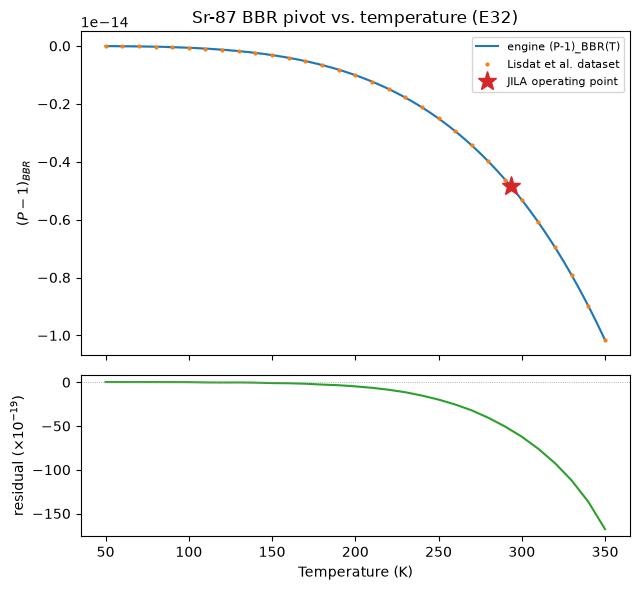

In [5]:
nu_0 = sr87.clock_frequency_hz

t_min_k, t_max_k = 50.0, 350.0
t_grid = np.linspace(t_min_k, t_max_k, 301)
engine_vals = np.array([bbr_pivot_perturbation(float(t), sr87) for t in t_grid])
engine_sigma = np.array([bbr_pivot_uncertainty(float(t), sr87)[0] for t in t_grid])

dataset_path = Path("..") / "benchmarks" / "data" / "lisdat2021_dataset" / "BBR_shift.dat"
dataset = np.genfromtxt(dataset_path, skip_header=2, delimiter="\t", usecols=(0, 1, 2, 3, 4))
t_dataset = dataset[:, 0]
total_shift_hz = dataset[:, 1]
window = (t_dataset >= t_min_k) & (t_dataset <= t_max_k)
t_dataset_w = t_dataset[window]
dataset_frac_w = total_shift_hz[window] / nu_0

engine_at_dataset_t = np.array([bbr_pivot_perturbation(float(t), sr87) for t in t_dataset_w])
residual_frac = engine_at_dataset_t - dataset_frac_w

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(6.5, 6.0), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)
ax_top.plot(t_grid, engine_vals, color="C0", label="engine (P-1)_BBR(T)")
ax_top.fill_between(
    t_grid, engine_vals - engine_sigma, engine_vals + engine_sigma, color="C0", alpha=0.2
)
ax_top.plot(
    t_dataset_w, dataset_frac_w, ".", color="C1", markersize=4, label="Lisdat et al. dataset"
)
ax_top.plot(
    [case.temperature_k],
    [case.predicted_shift_nominal],
    "*",
    color="C3",
    markersize=14,
    label="JILA operating point",
)
ax_top.set_ylabel(r"$(P-1)_{BBR}$")
ax_top.set_title("Sr-87 BBR pivot vs. temperature (E32)")
ax_top.legend(fontsize=8)

ax_bot.plot(t_dataset_w, residual_frac / 1e-19, color="C2")
ax_bot.axhline(0.0, color="0.6", lw=0.6, ls=":")
ax_bot.set_xlabel("Temperature (K)")
ax_bot.set_ylabel(r"residual ($\times 10^{-19}$)")
fig.tight_layout()
plt.show()

## 5. What this demonstrates

This case establishes that the engine's BBR arithmetic and coefficient
provenance chain are correct end to end. The registry coefficients, run
through the real `bbr_pivot_perturbation`/`bbr_pivot_uncertainty`
functions and through the full declarative pipeline alike, land inside
JILA's own published band. The two routes agree with each other to
machine precision.

The one caveat worth carrying forward is the class label: JILA's own
row is a computed number, and the registry's coefficients were rescaled
to match it. The residual panel above is therefore the expected offset
that rescaling introduces relative to the older Lisdat dataset. This
case stays outside the project's reproducibility headline count
(`docs/validation.md`, `benchmarks/RESULTS.md`).